Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


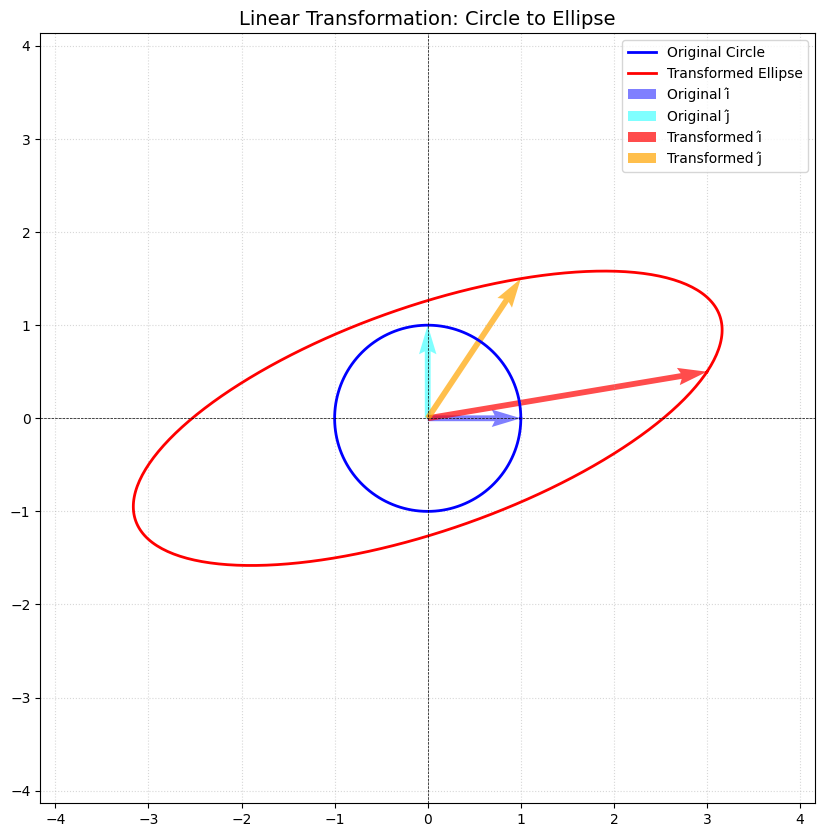

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_matrix_transformation():
    # 1. Generate points for a unit circle
    theta = np.linspace(0, 2 * np.pi, 300)
    # x and y coordinates of the circle
    x = np.cos(theta)
    y = np.sin(theta)
    
    # Combine into a 2xN matrix where each column is a 2D point vector
    circle_points = np.vstack((x, y))

    # 2. Define the transformation matrix (A)
    # This matrix scales the x-axis by 3, scales the y-axis by 1.5,
    # and introduces a shear to rotate/stretch it dynamically.
    A = np.array([
        [3.0, 1.0],
        [0.5, 1.5]
    ])

    # 3. Apply the transformation via matrix multiplication
    # New_Points = A * Old_Points
    transformed_points = np.dot(A, circle_points)

    # 4. Plotting the results
    plt.figure(figsize=(10, 10))
    
    # Plot original circle
    plt.plot(circle_points[0, :], circle_points[1, :], 
             label='Original Circle', color='blue', linewidth=2)
    
    # Plot transformed ellipse
    plt.plot(transformed_points[0, :], transformed_points[1, :], 
             label='Transformed Ellipse', color='red', linewidth=2)
    
    # Plot basis vectors to show how space itself distorted
    # Original basis vectors
    plt.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.5, label='Original î')
    plt.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1, color='cyan', alpha=0.5, label='Original ĵ')
    
    # Transformed basis vectors (these are just the columns of matrix A!)
    plt.quiver(0, 0, A[0,0], A[1,0], angles='xy', scale_units='xy', scale=1, color='red', alpha=0.7, label='Transformed î')
    plt.quiver(0, 0, A[0,1], A[1,1], angles='xy', scale_units='xy', scale=1, color='orange', alpha=0.7, label='Transformed ĵ')

    # Formatting the plot
    plt.axhline(0, color='black',linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black',linewidth=0.5, linestyle='--')
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    
    # Equal scaling ensures circles don't look like ellipses due to screen stretching
    plt.axis('equal') 
    
    # Dynamic limits based on transformation
    max_val = np.max(np.abs(transformed_points)) + 1
    plt.xlim(-max_val, max_val)
    plt.ylim(-max_val, max_val)
    
    plt.title('Linear Transformation: Circle to Ellipse', fontsize=14)
    plt.legend(loc='upper right')
    plt.show()

if __name__ == "__main__":
    simulate_matrix_transformation()